Setup Library & Integrasi Data (Load Data).

In [9]:
import pandas as pd
from pathlib import Path
import warnings

# Menonaktifkan warning agar output notebook tetap rapi dan profesional
warnings.filterwarnings('ignore')

# Sesuaikan dengan path Windows kamu
DATA_DIR = Path(r".\dataset")

# Menyiapkan wadah untuk memisahkan data
list_df_lama = []
df_baru = pd.DataFrame()

print("Membaca dan menyeleksi dataset...\n")

for p in DATA_DIR.glob('*.xls'):
    try:
        # Membaca file HTML yang berekstensi .xls
        df_temp = pd.read_html(p)[0]
        # Standarisasi nama kolom ke huruf kecil dan hilangkan spasi ekstra
        df_temp.columns = df_temp.columns.str.lower().str.strip()
        
        total_baris = len(df_temp)
        
        # Logika penyortiran otomatis
        if total_baris >= 3000:
            df_baru = df_temp
            print(f"[DATA BARU] Berhasil dimuat: {p.name} ({total_baris} baris)")
            
        elif total_baris >= 1500:
            # Menambahkan kolom sumber file untuk pelacakan jika dibutuhkan nanti
            df_temp['source_file'] = p.name
            list_df_lama.append(df_temp)
            print(f"[DATA LAMA] Berhasil dimuat: {p.name} ({total_baris} baris)")
            
        else:
            # Mengabaikan file agregasi (300-an baris)
            print(f"[DIABAIKAN] Data Agregasi/Tidak Lengkap: {p.name} ({total_baris} baris)")
            
    except Exception as e:
        print(f"❌ Gagal memproses {p.name}: {e}")

# Menggabungkan semua list data lama menjadi satu DataFrame utuh
if list_df_lama:
    df_lama = pd.concat(list_df_lama, ignore_index=True)

print("\n="*50)
print("RINGKASAN DATASET INTEGRASI")
print("="*50)
print(f"DataFrame LAMA (Tanpa PM2.5) : {df_lama.shape[0]} baris, {df_lama.shape[1]} kolom")
print(f"DataFrame BARU (Dengan PM2.5): {df_baru.shape[0]} baris, {df_baru.shape[1]} kolom")

Membaca dan menyeleksi dataset...

[DATA BARU] Berhasil dimuat: Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta - tabel.xls (3501 baris)
[DATA LAMA] Berhasil dimuat: Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta 2023 - tabel.xls (1825 baris)
[DATA LAMA] Berhasil dimuat: Data_Indeks Standar Pencemaran Udara di SPKU DKI Jakarta Tahun 2018 - tabel.xls (1825 baris)
[DATA LAMA] Berhasil dimuat: Data_Indeks Standar Pencemaran Udara DKI Jakarta Tahun 2017 - tabel.xls (1825 baris)
[DATA LAMA] Berhasil dimuat: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2010 - tabel.xls (1825 baris)
[DIABAIKAN] Data Agregasi/Tidak Lengkap: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2011 - tabel.xls (365 baris)
[DIABAIKAN] Data Agregasi/Tidak Lengkap: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2012 - tabel.xls (366 baris)
[DIABAIKAN] Data Agregasi/Tidak Lengkap: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2013 - tabel.xls (365 baris)
[DATA LAMA] Berhasil dimuat: Indeks

Data Cleaning & Imputasi

In [10]:
import numpy as np

print("=== TAHAP 2: DATA CLEANING & STANDARISASI ===\n")

# 1. Fungsi untuk menyeragamkan nama kolom (Versi Anti-Error Pandas Baru)
def standarisasi_kolom(df):
    kolom_mapping = {
        'wilayah': 'stasiun',
        'lokasi_spku': 'stasiun',
        'pm_sepuluh': 'pm10',
        'pm_duakomalima': 'pm25',
        'sulfur_dioksida': 'so2',
        'karbon_monoksida': 'co',
        'ozon': 'o3',
        'nitrogen_dioksida': 'no2',
        'parameter_pencemar_kritis': 'critical',
        'categori': 'kategori'
    }
    df_renamed = df.rename(columns=kolom_mapping)
    
    # Menggabungkan kolom yang memiliki nama kembar secara aman
    new_cols = {}
    for col in df_renamed.columns.unique():
        if isinstance(df_renamed[col], pd.DataFrame):
            # bfill(axis=1) akan menutupi NaN dengan data di kolom sebelahnya
            new_cols[col] = df_renamed[col].bfill(axis=1).iloc[:, 0]
        else:
            new_cols[col] = df_renamed[col]
            
    return pd.DataFrame(new_cols)

print("Standarisasi nama kolom...")
df_lama_clean = standarisasi_kolom(df_lama)
df_baru_clean = standarisasi_kolom(df_baru)

# 2. Fungsi pembersihan isi data (stasiun, polutan, dan target)
def clean_isi_data(df, is_baru=False):
    df = df.copy()
    
    # Standarisasi nama stasiun
    def bersihkan_stasiun(nama):
        nama = str(nama).upper()
        if 'DKI1' in nama: return 'DKI1'
        elif 'DKI2' in nama: return 'DKI2'
        elif 'DKI3' in nama: return 'DKI3'
        elif 'DKI4' in nama: return 'DKI4'
        elif 'DKI5' in nama: return 'DKI5'
        else: return np.nan
        
    df['stasiun'] = df['stasiun'].apply(bersihkan_stasiun)
    df = df.dropna(subset=['stasiun'])
    
    # Menentukan kolom polutan yang akan dibersihkan
    kolom_polutan = ['pm10', 'so2', 'co', 'o3', 'no2']
    if is_baru and 'pm25' in df.columns:
        kolom_polutan.append('pm25') # PM2.5 khusus untuk data baru
        
    # Konversi ke angka desimal & Imputasi Median per stasiun
    for col in kolom_polutan:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df.groupby('stasiun')[col].transform(lambda x: x.fillna(x.median()))
            
    # Bersihkan target (kategori)
    df = df.dropna(subset=['kategori'])
    df['kategori'] = df['kategori'].astype(str).str.upper().str.strip()
    
    # Buang kelas ekstrem (BERBAHAYA) jika jumlahnya tidak signifikan
    kategori_valid = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT']
    df = df[df['kategori'].isin(kategori_valid)]
    
    # Buang kolom yang tidak perlu untuk modeling (Mencegah Data Leakage)
    kolom_buang = ['periode_data', 'tanggal', 'bulan', 'max', 'critical', 'source_file']
    df = df.drop(columns=[col for col in kolom_buang if col in df.columns])
    
    # Khusus data lama, pastikan PM2.5 tidak nyangkut dari proses sebelumnya
    if not is_baru and 'pm25' in df.columns:
        df = df.drop(columns=['pm25'])
        
    return df

print("Imputasi missing values dan perapihan isi data...")
df_lama_final = clean_isi_data(df_lama_clean, is_baru=False)
df_baru_final = clean_isi_data(df_baru_clean, is_baru=True)

print("\n" + "="*50)
print("✅ TAHAP CLEANING SELESAI!")
print("="*50)
print(f"Bentuk Data LAMA : {df_lama_final.shape[0]} baris.")
print(f"Kolom Data LAMA  : {df_lama_final.columns.tolist()}\n")

print(f"Bentuk Data BARU : {df_baru_final.shape[0]} baris.")
print(f"Kolom Data BARU  : {df_baru_final.columns.tolist()}")

=== TAHAP 2: DATA CLEANING & STANDARISASI ===

Standarisasi nama kolom...
Imputasi missing values dan perapihan isi data...

✅ TAHAP CLEANING SELESAI!
Bentuk Data LAMA : 10963 baris.
Kolom Data LAMA  : ['stasiun', 'pm10', 'so2', 'co', 'o3', 'no2', 'kategori']

Bentuk Data BARU : 3480 baris.
Kolom Data BARU  : ['stasiun', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'kategori']


Exploratory Data Analysis (EDA

=== TAHAP 3: EXPLORATORY DATA ANALYSIS (EDA) & SETUP SKENARIO ===

Skenario A (tanpa PM2.5): 14443 baris
Skenario B (termasuk PM2.5): 3480 baris



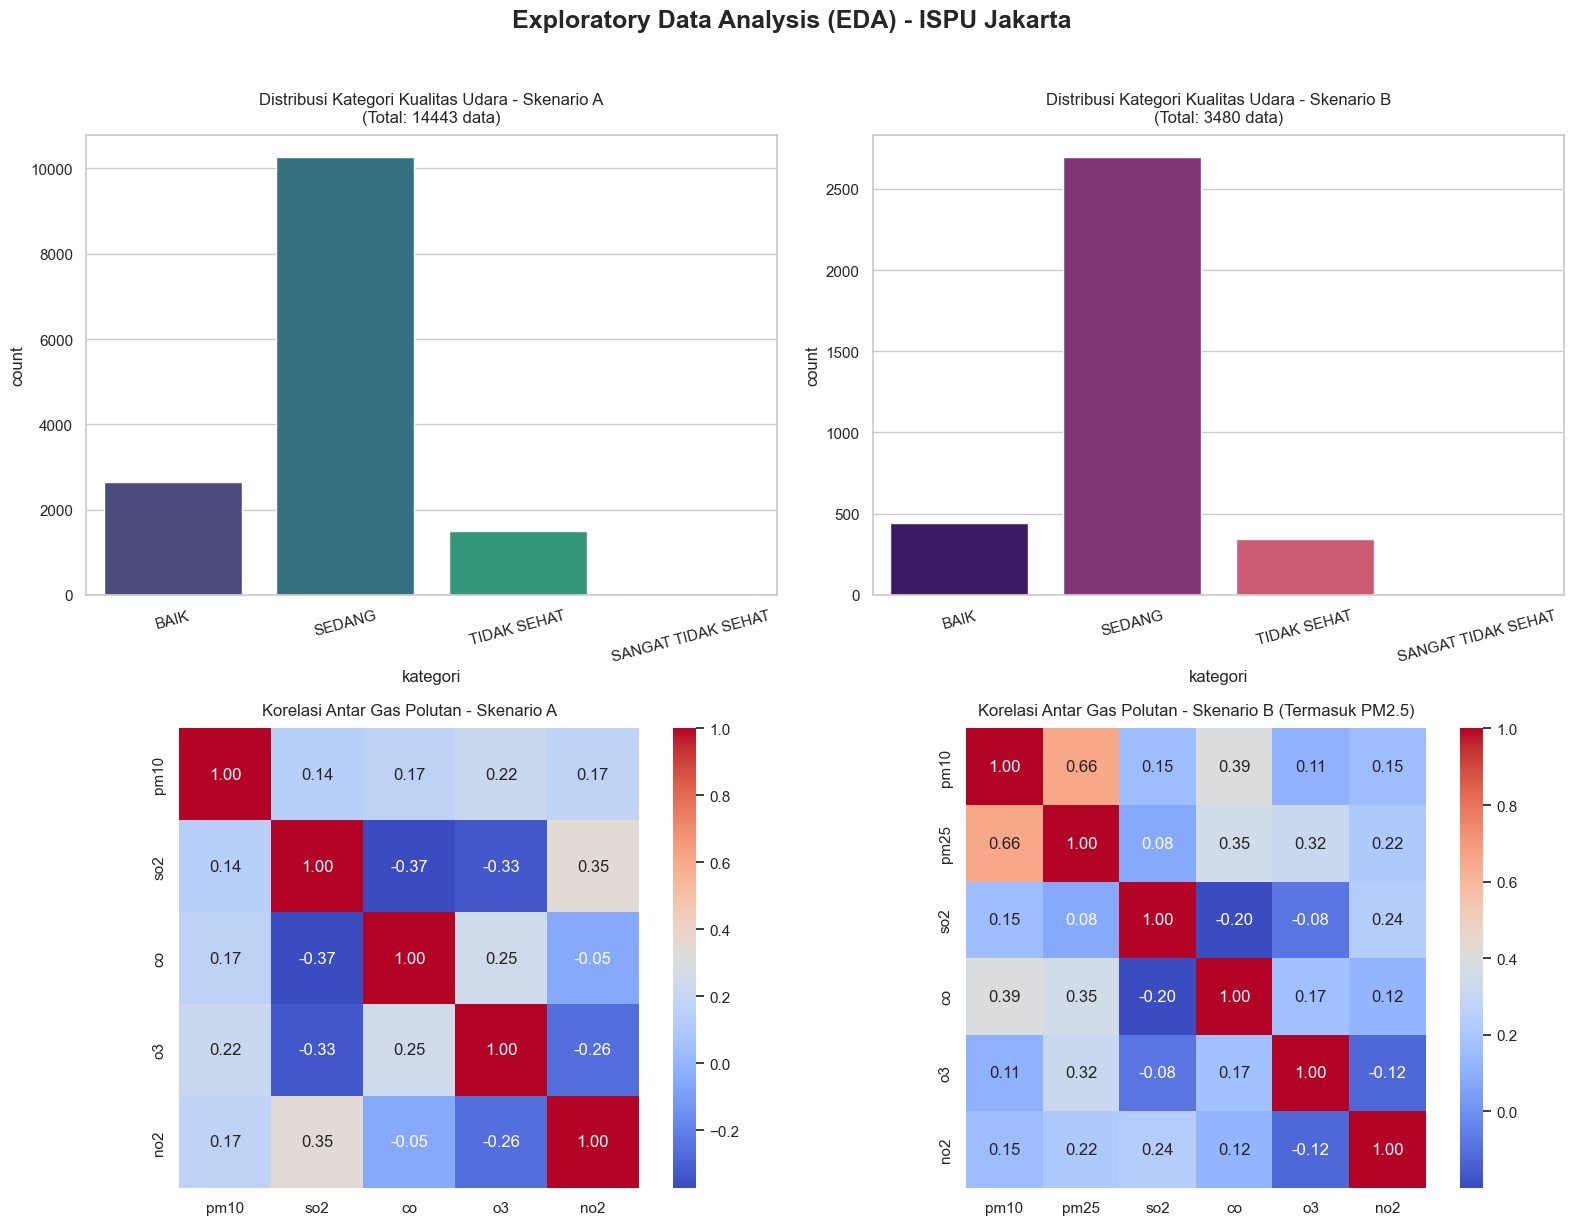

Visualisasi EDA disimpan sebagai 'eda_ispu_ab_testing.png'


In [11]:
# ==========================================
# CELL 3: TAHAP 3 - EDA & SETUP SKENARIO A/B
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=== TAHAP 3: EXPLORATORY DATA ANALYSIS (EDA) & SETUP SKENARIO ===\n")

# 1. SETUP SKENARIO SESUAI STRATEGI KITA
# Skenario A: Gabungan SEMUA data (lama + baru), tapi PM2.5 di-drop
df_baru_tanpa_pm25 = df_baru_final.drop(columns=['pm25'])
df_skenario_A = pd.concat([df_lama_final, df_baru_tanpa_pm25], ignore_index=True)

# Skenario B: Khusus data baru (punya PM2.5)
df_skenario_B = df_baru_final.copy()

print(f"Skenario A (tanpa PM2.5): {df_skenario_A.shape[0]} baris")
print(f"Skenario B (termasuk PM2.5): {df_skenario_B.shape[0]} baris\n")

# 2. VISUALISASI EDA (EXPLORATORY DATA ANALYSIS)
# Menggunakan style bawaan seaborn agar grafiknya terlihat elegan untuk laporan
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis (EDA) - ISPU Jakarta', fontsize=18, fontweight='bold', y=1.02)

# Grafik 1: Distribusi Target Skenario A
sns.countplot(data=df_skenario_A, x='kategori', ax=axes[0,0], palette='viridis', 
              order=['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT'])
axes[0,0].set_title(f'Distribusi Kategori Kualitas Udara - Skenario A\n(Total: {len(df_skenario_A)} data)', pad=10)
axes[0,0].tick_params(axis='x', rotation=15)

# Grafik 2: Distribusi Target Skenario B
sns.countplot(data=df_skenario_B, x='kategori', ax=axes[0,1], palette='magma',
              order=['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT'])
axes[0,1].set_title(f'Distribusi Kategori Kualitas Udara - Skenario B\n(Total: {len(df_skenario_B)} data)', pad=10)
axes[0,1].tick_params(axis='x', rotation=15)

# Grafik 3: Heatmap Korelasi Polutan Skenario A
# Cuma ngambil kolom angka (polutan) buat ngecek gas mana yang sering naik barengan
corr_A = df_skenario_A.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr_A, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1,0], square=True)
axes[1,0].set_title('Korelasi Antar Gas Polutan - Skenario A', pad=10)

# Grafik 4: Heatmap Korelasi Polutan Skenario B
corr_B = df_skenario_B.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr_B, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1,1], square=True)
axes[1,1].set_title('Korelasi Antar Gas Polutan - Skenario B (Termasuk PM2.5)', pad=10)

plt.tight_layout()
nama_gambar_eda = 'eda_ispu_ab_testing.png'
plt.savefig(nama_gambar_eda, dpi=300, bbox_inches='tight')
plt.show()

print(f"Visualisasi EDA disimpan sebagai '{nama_gambar_eda}'")

Feature Engineering

In [12]:
# ==========================================
# CELL 4: FEATURE ENGINEERING
# ==========================================
print("=== TAHAP 4: FEATURE ENGINEERING ===\n")

def siapkan_fitur_target(df):
    df_copy = df.copy()
    
    # 1. Encoding Label Kategori (Ordinal)
    # Urutan dari yang paling sehat (0) ke paling bahaya (3)
    map_kategori = {'BAIK': 0, 'SEDANG': 1, 'TIDAK SEHAT': 2, 'SANGAT TIDAK SEHAT': 3}
    df_copy['kategori'] = df_copy['kategori'].map(map_kategori)
    
    # 2. One-Hot Encoding untuk Lokasi Stasiun
    # drop_first=True untuk menghindari jebakan statistik (dummy variable trap)
    df_copy = pd.get_dummies(df_copy, columns=['stasiun'], drop_first=True)
    
    # Konversi nilai boolean (True/False) hasil get_dummies menjadi angka murni (1/0)
    for col in df_copy.select_dtypes(include=['bool']).columns:
        df_copy[col] = df_copy[col].astype(int)
        
    # 3. Pisahkan Fitur (X) dan Target (y)
    X = df_copy.drop(columns=['kategori'])
    y = df_copy['kategori']
    
    return X, y

print("Memproses Skenario A (tanpa PM2.5)...")
X_A, y_A = siapkan_fitur_target(df_skenario_A)

print("Memproses Skenario B (termasuk PM2.5)...")
X_B, y_B = siapkan_fitur_target(df_skenario_B)

print("Feature engineering selesai.")
print(f"Dimensi Skenario A -> X_A: {X_A.shape} | y_A: {y_A.shape}")
print(f"Dimensi Skenario B -> X_B: {X_B.shape} | y_B: {y_B.shape}")

print("Cek 3 baris pertama X_B:")
display(X_B.head(3))

=== TAHAP 4: FEATURE ENGINEERING ===

Memproses Skenario A (tanpa PM2.5)...
Memproses Skenario B (termasuk PM2.5)...
Feature engineering selesai.
Dimensi Skenario A -> X_A: (14443, 9) | y_A: (14443,)
Dimensi Skenario B -> X_B: (3480, 10) | y_B: (3480,)
Cek 3 baris pertama X_B:


,pm10,pm25,so2,co,o3,no2,stasiun_DKI2,stasiun_DKI3,stasiun_DKI4,stasiun_DKI5
0,51.0,65.0,45.0,9.0,8.0,79.0,0,1,0,0
1,27.0,34.0,45.0,5.0,8.0,56.0,0,1,0,0
2,49.0,52.0,46.0,6.0,9.0,51.0,0,1,0,0


Pemodelan & Pelatihan AI (Modeling).

In [13]:
# ==========================================
# CELL 5: PEMODELAN & PELATIHAN RANDOM FOREST (REVISI)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("=== TAHAP 5: SPLIT DATA & PELATIHAN MODEL ===\n")

print("Memeriksa dan membersihkan kelas langka...")

# 1. Filter Skenario A (Memastikan semua kelas punya minimal 2 sampel)
counts_A = y_A.value_counts()
kelas_valid_A = counts_A[counts_A >= 2].index
X_A = X_A[y_A.isin(kelas_valid_A)]
y_A = y_A[y_A.isin(kelas_valid_A)]

# 2. Filter Skenario B (Membuang kategori SANGAT TIDAK SEHAT yang cuma ada 1 data)
counts_B = y_B.value_counts()
kelas_valid_B = counts_B[counts_B >= 2].index

if len(counts_B) != len(kelas_valid_B):
    kelas_dibuang = counts_B[counts_B < 2].index.tolist()
    print(f"Catatan: Kelas indeks {kelas_dibuang} di Skenario B dikeluarkan")
    print(f"Karena sampel terlalu sedikit untuk dibagi ke data latih dan uji.")

X_B = X_B[y_B.isin(kelas_valid_B)]
y_B = y_B[y_B.isin(kelas_valid_B)]


# 3. PEMBAGIAN DATA (TRAIN-TEST SPLIT)
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y_A, test_size=0.2, random_state=42, stratify=y_A
)

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B, test_size=0.2, random_state=42, stratify=y_B
)

print(f"\n📊 PEMBAGIAN PORSI DATA BERHASIL:")
print(f"Skenario A -> Data Latih: {X_train_A.shape[0]} baris | Data Uji: {X_test_A.shape[0]} baris")
print(f"Skenario B -> Data Latih: {X_train_B.shape[0]} baris | Data Uji: {X_test_B.shape[0]} baris\n")


# 4. PELATIHAN MODEL MACHINE LEARNING
print("Mulai pelatihan Model Skenario A...")
model_A = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_A.fit(X_train_A, y_train_A)
print("Model A selesai dilatih.\n")

print("Mulai pelatihan Model Skenario B...")
model_B = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_B.fit(X_train_B, y_train_B)
print("Model B selesai dilatih.")

print("Pelatihan selesai tanpa error.")

=== TAHAP 5: SPLIT DATA & PELATIHAN MODEL ===

Memeriksa dan membersihkan kelas langka...
Catatan: Kelas indeks [3] di Skenario B dikeluarkan
Karena sampel terlalu sedikit untuk dibagi ke data latih dan uji.

📊 PEMBAGIAN PORSI DATA BERHASIL:
Skenario A -> Data Latih: 11554 baris | Data Uji: 2889 baris
Skenario B -> Data Latih: 2783 baris | Data Uji: 696 baris

Mulai pelatihan Model Skenario A...
Model A selesai dilatih.

Mulai pelatihan Model Skenario B...
Model B selesai dilatih.
Pelatihan selesai tanpa error.


=== TAHAP 6: EVALUASI & KOMPARASI MODEL A VS B ===

SKOR AKURASI
Model Skenario A (Tanpa PM2.5 | 14k Data) : 92.87%
Model Skenario B (Pakai PM2.5  | 3.4k Data): 98.99%

Report: Skenario A
                    precision    recall  f1-score   support

              BAIK       0.90      0.89      0.90       528
            SEDANG       0.94      0.97      0.95      2053
       TIDAK SEHAT       0.92      0.74      0.82       299
SANGAT TIDAK SEHAT       1.00      1.00      1.00         9

          accuracy                           0.93      2889
         macro avg       0.94      0.90      0.92      2889
      weighted avg       0.93      0.93      0.93      2889

Report: Skenario B
              precision    recall  f1-score   support

        BAIK       1.00      0.93      0.97        89
      SEDANG       0.99      1.00      0.99       539
 TIDAK SEHAT       1.00      0.99      0.99        68

    accuracy                           0.99       696
   macro avg       1.00      0.97     

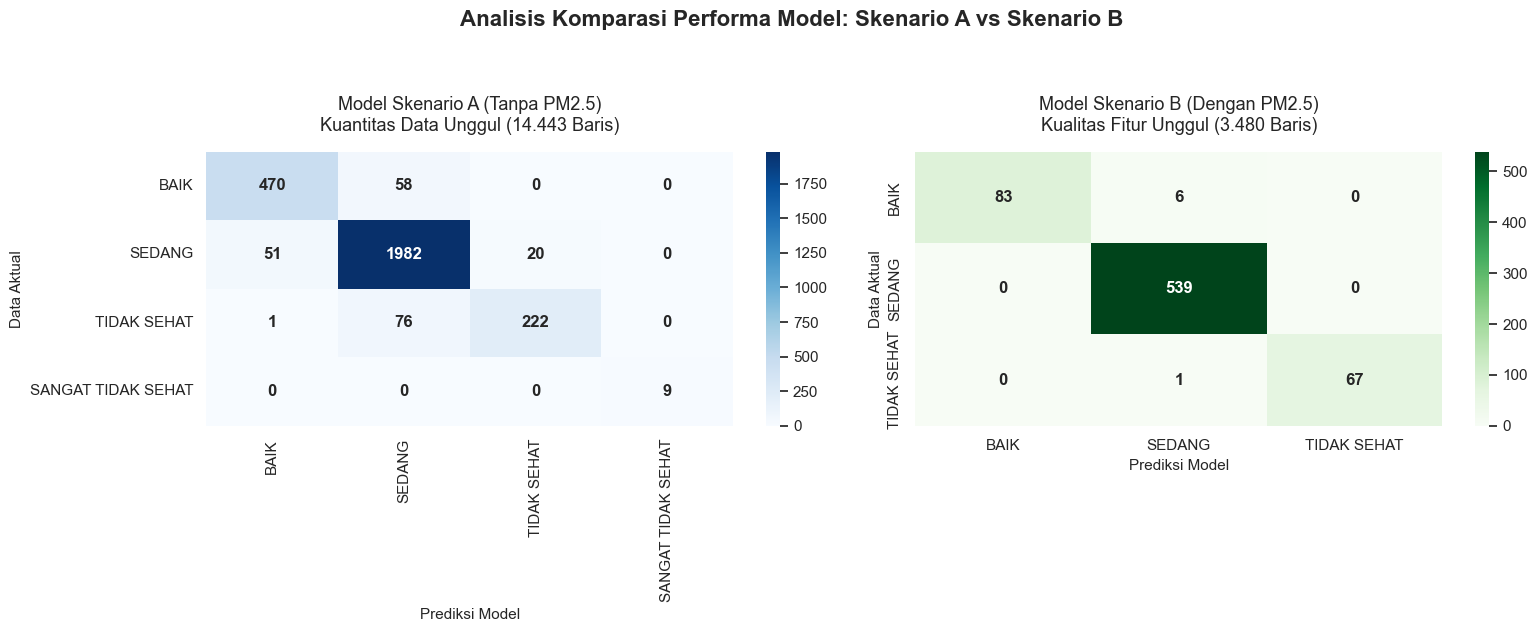

Grafik komparasi disimpan sebagai 'komparasi_model_ispu.png'


In [14]:
# ==========================================
# CELL 6: EVALUASI & KOMPARASI MODEL A VS B
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("=== TAHAP 6: EVALUASI & KOMPARASI MODEL A VS B ===\n")

# 1. Melakukan Prediksi menggunakan Data Uji masing-masing Skenario
y_pred_A = model_A.predict(X_test_A)
y_pred_B = model_B.predict(X_test_B)

# Menentukan label target yang sesuai dengan kondisi data saat ini
target_names_A = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT']
target_names_B = ['BAIK', 'SEDANG', 'TIDAK SEHAT'] # SANGAT TIDAK SEHAT sudah di-drop di B

# 2. Menampilkan Skor Akurasi Total
print("="*60)
print("SKOR AKURASI")
print("="*60)
print(f"Model Skenario A (Tanpa PM2.5 | 14k Data) : {accuracy_score(y_test_A, y_pred_A)*100:.2f}%")
print(f"Model Skenario B (Pakai PM2.5  | 3.4k Data): {accuracy_score(y_test_B, y_pred_B)*100:.2f}%\n")

# 3. Menampilkan Classification Report Detail
print("="*60)
print("Report: Skenario A")
print("="*60)
print(classification_report(y_test_A, y_pred_A, target_names=target_names_A))

print("="*60)
print("Report: Skenario B")
print("="*60)
print(classification_report(y_test_B, y_pred_B, target_names=target_names_B))

# 4. Visualisasi Komparasi Confusion Matrix Berdampingan
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analisis Komparasi Performa Model: Skenario A vs Skenario B', fontsize=16, fontweight='bold', y=1.05)

# Matriks Skenario A
cm_A = confusion_matrix(y_test_A, y_pred_A)
sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names_A, yticklabels=target_names_A,
            annot_kws={"size": 12, "weight": "bold"})
axes[0].set_title('Model Skenario A (Tanpa PM2.5)\nKuantitas Data Unggul (14.443 Baris)', pad=15, fontsize=13)
axes[0].set_xlabel('Prediksi Model', fontsize=11)
axes[0].set_ylabel('Data Aktual', fontsize=11)

# Matriks Skenario B
cm_B = confusion_matrix(y_test_B, y_pred_B)
sns.heatmap(cm_B, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=target_names_B, yticklabels=target_names_B,
            annot_kws={"size": 12, "weight": "bold"})
axes[1].set_title('Model Skenario B (Dengan PM2.5)\nKualitas Fitur Unggul (3.480 Baris)', pad=15, fontsize=13)
axes[1].set_xlabel('Prediksi Model', fontsize=11)
axes[1].set_ylabel('Data Aktual', fontsize=11)

plt.tight_layout()
nama_file_komparasi = 'komparasi_model_ispu.png'
plt.savefig(nama_file_komparasi, dpi=300, bbox_inches='tight')
plt.show()

print(f"Grafik komparasi disimpan sebagai '{nama_file_komparasi}'")